In [1]:
import torch 
import torch.nn as nn
import numpy as np
from core import *
from core.basemodel import *
from core.data_handler import *
from core.optimizer import *
from core.fit import *
import core.cbs as cbs
import torch.distributions as torchdist
import matplotlib.pyplot as plt

from collections import OrderedDict

In [2]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

# Data

In [3]:
bs = 1
seq_len = 50
overlap=0

In [4]:
trn_ , val_ = split('../dataset/fuz attack/generated_ds/v2/train/',prc = 0.2, dataset_pct=  1, dim =(1), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/generated_ds/amr/test/',prc = 0 , dataset_pct=  1, dim = (1), word_type=torch.float)

In [5]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[1])
val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[1])
anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[1])

In [6]:
dl =CombineDataLoader(trn_dl,val_dl)

In [9]:
a = next(iter(dl.trn_dl))

In [7]:
len(trn_dl)+len(val_dl)

131

In [8]:
def iterator(dl):
    a=[]
    for i in dl:
        l = i.numpy()[0]
        a.append(l.mean())
    return a

In [9]:
trn_path = iterator(trn_dl)
val_path = iterator(val_dl)
anml_path = iterator(anml_dl)

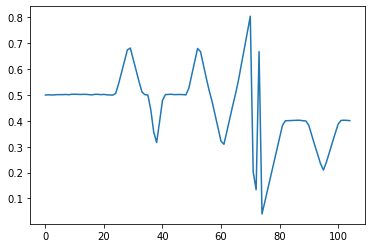

In [10]:
plt.plot(trn_path)
#plt.plot(np.array(trn_lka.detach()))

## Model

In [11]:
from lka_model import *

In [12]:
def generate_lka():
    str1 =torch.randint(0,2,(23,))
    steer1 = str1[-1].repeat(19)
    str2 = torch.randint(0,2,(6,))
    switch1 = torch.zeros(34)
    str3 = torch.randint(0,2,(8,))
    steer2 = str2[-1].repeat(15)
    
    trn_lka = torch.cat([str1,steer1,str2,switch1,str3,steer2]).type(torch.float)
    
    val_lka = torch.clone(torch.cat([torch.zeros(2),torch.ones(2)])).repeat(10).type(torch.float)
    train_cat = torch.cat([trn_lka, val_lka])

    return train_cat

In [13]:
a = generate_lka()

In [14]:
#def generate_lka(seq_len=10):
    str1 =torch.randint(0,2,(130,))
    steer1 = str1[-1].repeat(95)
    str2 = torch.randint(0,2,(40,))
    switch1 = torch.zeros(185)
    str3 = torch.randint(0,2,(30,))
    steer2 = str2[-1].repeat(92)
    
    trn_lka = torch.cat([str1,steer1,str2,switch1,str3,steer2]).type(torch.float)
    
    val_lka = torch.clone(torch.cat([torch.zeros(5),torch.ones(5)])).repeat(15).type(torch.float)
    train_cat = torch.cat([trn_lka, val_lka])

    return train_cat

IndentationError: unexpected indent (<ipython-input-14-194fa9421ec1>, line 2)

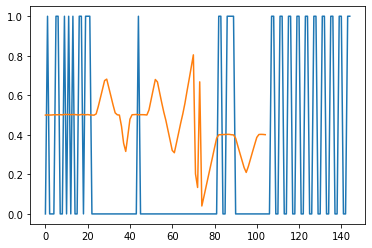

In [15]:
plt.plot(a)
plt.plot(trn_path)

# Custom Loss

In [16]:
class mse:
    def __call__(self,ip,tgt):
        #### LKA PART ####
        tgt_lka,op_lka,(rcn_rld,tgt_rld) = ip
        lka_loss = nn.functional.mse_loss(op_lka,tgt_lka)
        #### Reconstruction part ####
        rcn_loss = nn.functional.mse_loss(rcn_rld,tgt_rld)
        return (lka_loss  + rcn_loss)/2          

In [17]:
class bce:
    def __call__(self,ip,tgt):
        
        tgt_lka,op_lka,(rcn_rld,tgt_rld) = ip
        #print(op_lka.view(-1).shape,tgt_lka.view(-1).shape)
        lka_loss = nn.functional.binary_cross_entropy(op_lka.view(-1),tgt_lka.view(-1))
        return lka_loss            

In [84]:
def nll(ip,tgt): 
    tgt_lka,op_lka,(_,_) = ip
    
    bs = tgt_lka.shape[0]
    lka_loss = nn.functional.nll_loss(op_lka.view(bs,2),tgt_lka.type(torch.LongTensor).cuda())
    return lka_loss          

In [85]:
def mixed_nll(ip,tgt):
    tgt_lka,op_lka,(rcn_rld,tgt_rld) = ip
    ber_l = nll(ip,ip)
    norm_l = nnl_nd((rcn_rld,tgt_rld),None)
    return (ber_l+norm_l)/2     

In [86]:
def nnl_nd(x_pred,x_target): #x_pred = batchsize,2[mean,var], x_target = batchsize,1[feature]
    x_pred,x_target = x_pred
    x_u = x_target[...,0]
    var = torch.exp(x_pred[...,1])
    
    dist = torchdist.normal.Normal(x_u,var)
    likelhood = dist.log_prob(x_target)
    result = torch.mean(-likelhood)
    
    return result
    

In [87]:
def ml_eval(x_pred): #x_pred = batchsize,2[mean,var]
    
    x_u = x_pred[:,0]
    var = torch.exp(x_pred[:,1])
    
    dist = torchdist.normal.Normal(x_u,var)
    
    return dist

# Model : Predict LKA

In [88]:
class mixed_nll_lka_predictor(BaseModel):    
    def __init__(self,bs,seq_len,rcn_w = 10,compress_hs=10,max_count = 131):
        super().__init__()
        self.bs,self.seq_len = bs,seq_len

        
        self.lka_cmp = nn.Sequential(nn.Linear(2+compress_hs,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1),
                                            nn.Sigmoid())
        
        self.rld_cmp = nn.Sequential(nn.Linear(seq_len+compress_hs,compress_hs,compress_hs),
                                            nn.PReLU())
        self.rld_rcn = nn.Sequential(nn.Linear(compress_hs,rcn_w*2))
        
        self.drop = nn.Dropout(p=0.4)
        
        #### LKA - Training - RLD Variables ###
        self.lka,self.mb_count,self.max_count,self.rcn_w  = None , 0, max_count,rcn_w
        self.p_lka = torch.zeros(self.bs).type(torch.float).cuda()
        self.rld = torch.tensor([0.5]*compress_hs).cuda()
        self.attn = nn.Sequential(nn.Linear(1,2),nn.Softmax())
        #### Storage Elements####
        self.RLD_hist = []
        
    def forward(self,x):
        #########RLD COMPRESSION##########
        self.rld = self.rld_cmp(torch.cat([x.squeeze(),self.rld]))
        ########END OF RLD COMPRESSION####
        if self.mb_count == 0:
            self.lka = generate_lka()
        #Get the history of vis from previous vis and all the past frames
        x_drop = self.drop(x.squeeze()).ceil() *x.squeeze()
        
        cat = torch.cat([self.p_lka.view(self.bs),x_drop[-1].view(1),self.rld],dim=-1)
        
        attn = self.lka_cmp(cat)
        predected_lka = self.attn(attn*self.p_lka)
        #### Updates for LKA - RLD history - Minibatch counter ####
        self.rld = self.rld.detach()
        self.p_lka = self.lka[self.mb_count: self.mb_count+self.bs].cuda()
        self.RLD_hist.extend(x.view(-1).detach().cpu().numpy())
        self.mb_count =(self.mb_count+self.bs)%self.max_count
        
        #### Reconstruction ####
        if len(self.RLD_hist) > self.rcn_w:
            rcn_rld = self.rld_rcn(self.rld).view(-1,2)
            tgt_rld = torch.tensor(self.RLD_hist[-self.rcn_w:]).clone().cuda()
        else:
            rcn_rld = self.rld_rcn(self.rld).view(-1,2)[:len(self.RLD_hist),:]
            tgt_rld = torch.tensor(self.RLD_hist).clone().cuda()
        return self.p_lka,predected_lka,(rcn_rld,tgt_rld)

In [131]:
m = mixed_nll_lka_predictor(bs,seq_len,rcn_w=200,max_count=len(trn_dl)+len(val_dl),compress_hs=100).cuda()

In [132]:
opt = torch.optim.Adadelta(m.parameters(),lr=1e-2)#torch.optim.Adam(m.parameters(),5e-5)
opt = BaseOptimizer(opt)
learn = learner()

In [133]:
trn_item = Validate(trn_dl)
val_item = Validate(val_dl)
anml_item = Validate(anml_dl)

In [134]:
loss =nll

In [135]:
learn.fit(m , opt , 5 , dl,loss  )

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)
                                               

train Loss:  -0.49828827381134033   validation loss:  -0.48531782627105713
tensor(nan)


train Loss:  -0.50212562084198   validation loss:  -0.4853128492832184
tensor(nan)


train Loss:  -0.48342689871788025   validation loss:  -0.4853319525718689
tensor(nan)


train Loss:  -0.449801504611969   validation loss:  -0.48540157079696655
tensor(nan)


train Loss:  -0.5144779682159424   validation loss:  -0.4853819012641907
tensor(nan)


In [136]:
anml_lka = torch.clone(torch.cat([torch.zeros(3),torch.ones(3)])).repeat(18).type(torch.float)

In [137]:
loss=nll

In [138]:
m.mb_count = 1
m.p_lka = torch.zeros(m.bs).type(torch.float).cuda()
m.lka = anml_lka
mean,std=[],[]
for i in anml_dl:
    pred = m(i.cuda())
    mean.append(pred[1][1].detach().cpu())

/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


  0%|          | 0/72 [00:00<?, ?it/s]/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


testing...


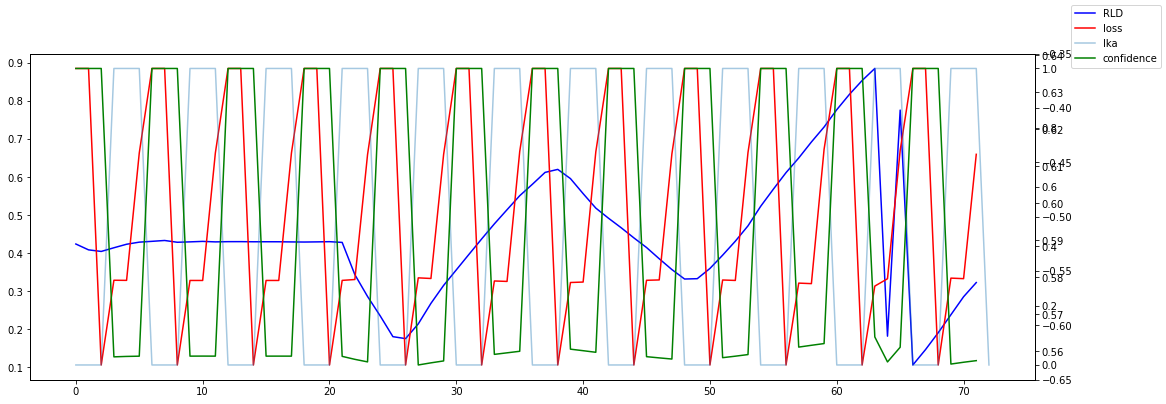

In [125]:
fig,ax1 = plt.subplots(figsize=(18,6))
m.mb_count = 1
m.p_lka = torch.zeros(m.bs).type(torch.float).cuda()
m.lka = anml_lka
anml_item.evaluate(model = m , crit = loss)
anml = np.array(anml_item.test_loss)
ax1.plot(torch.tensor(anml_path).cpu(),color='b',label='RLD')
ax2 = ax1.twinx()
ax2.plot(anml,color='r',label='loss')

ax3 = ax1.twinx()

ax3.plot(anml_lka[:73],label='lka',alpha=0.4)

ax4 = ax1.twinx()
ax4.plot(mean,label='confidence',alpha=1,color='g')

fig.legend()

/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


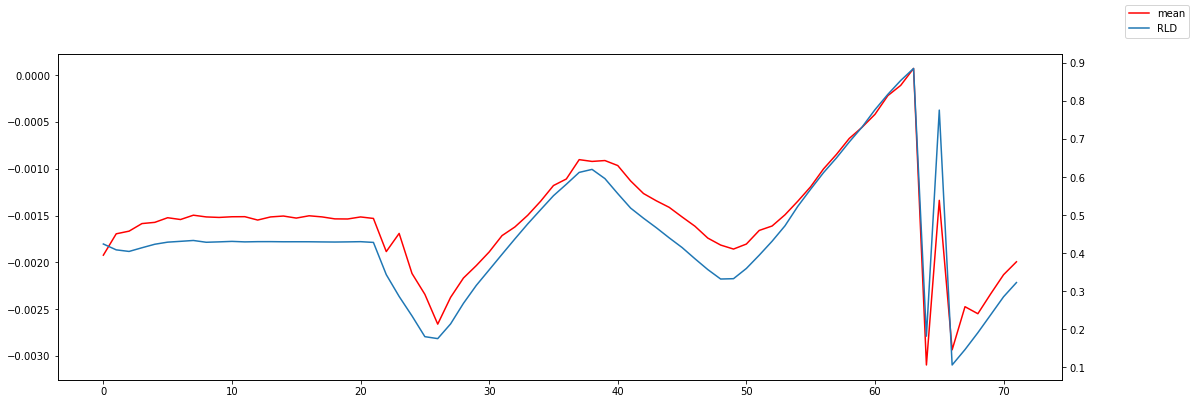

In [46]:
m.mb_count = 1
m.p_lka = torch.zeros(m.bs).type(torch.float).cuda()
m.lka = anml_lka
mean,std=[],[]
for i in anml_dl:
    _,_,pred = m(i.cuda())
    dist = ml_eval(pred[0])
    mean.append(pred[0][:,0].mean().detach().cpu())
    std.append(torch.sqrt(torch.exp(pred[0][:,1])).mean().detach().cpu())
s_p,s_n = np.array(mean)+np.array(std),np.array(mean)-np.array(std)
fig,ax = plt.subplots(figsize=(18,6)) 
ax.plot(mean,color='r',label='mean')
#ax.fill_between(range(len(s_p)),s_p,s_n,color='r',alpha=0.4,label='variance')
ax3 = ax.twinx()
ax3.plot(anml_path,label='RLD')
fig.legend()

/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


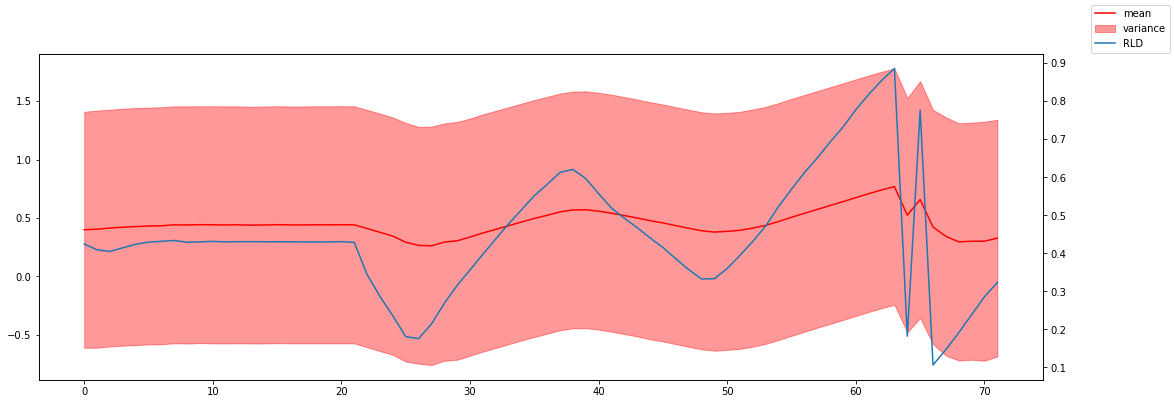

In [40]:
m.mb_count = 1
m.p_lka = torch.zeros(m.bs).type(torch.float).cuda()
m.lka = anml_lka
mean,std=[],[]

for i in anml_dl:
    _,_,pred = m(i.cuda())
    dist = ml_eval(pred[0])
    samples = dist.sample(torch.tensor([20]))
    samples = np.nan_to_num(samples.detach().cpu())
    mean.append(samples[:,0].mean())
    std.append(np.sqrt(np.exp(samples[:,1])).mean())
s_p,s_n = np.array(mean)+np.array(std),np.array(mean)-np.array(std)
fig,ax = plt.subplots(figsize=(18,6)) 
ax.plot(mean,color='r',label='mean')
ax.fill_between(range(len(s_p)),s_p,s_n,color='r',alpha=0.4,label='variance')
ax3 = ax.twinx()
ax3.plot(anml_path,label='RLD')
fig.legend()

/home/amr/anaconda3/envs/fast2/lib/python3.6/site-packages/torch/nn/modules/container.py:117: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


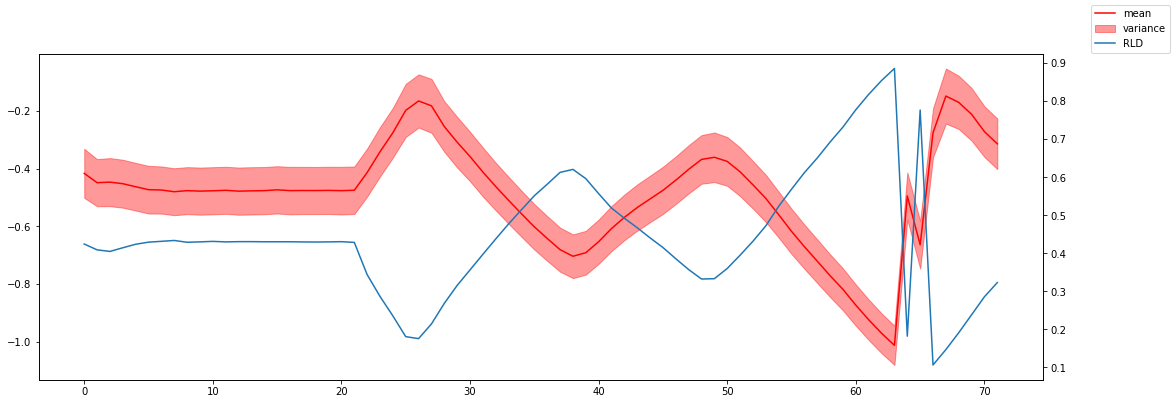

In [49]:
m.mb_count = 1
m.p_lka = torch.zeros(m.bs).type(torch.float).cuda()
m.lka = anml_lka
mean,std=[],[]

for i in anml_dl:
    _,_,pred = m(i.cuda())
    dist = ml_eval(pred[0])
    samples = dist.sample(torch.tensor([20]))
    samples = np.nan_to_num(samples.detach().cpu())
    mean.append(samples[:,0].mean())
    std.append(np.exp(samples[:,1]).mean())
s_p,s_n = np.array(mean)+np.array(std)/10,np.array(mean)-np.array(std)/10
fig,ax = plt.subplots(figsize=(18,6)) 
ax.plot(mean,color='r',label='mean')
ax.fill_between(range(len(s_p)),s_p,s_n,color='r',alpha=0.4,label='variance')
ax3 = ax.twinx()
ax3.plot(anml_path,label='RLD')
fig.legend()

## Models Store

In [ ]:
class seq_lka_predictor(BaseModel):    
    def __init__(self,bs,seq_len,rcn_w = 10,compress_hs=10,max_count = 131):
        super().__init__()
        self.bs,self.seq_len = bs,seq_len

        
        self.lka_cmp = nn.Sequential(nn.Linear(12,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024*1),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,2),
                                            nn.Softmax())
        
        self.rld_cmp = nn.Sequential(nn.Linear(60,compress_hs),
                                            nn.PReLU())
        self.rld_rcn = nn.Sequential(nn.Linear(compress_hs,rcn_w*2),
                                            nn.PReLU())
        
        self.drop = nn.Dropout(p=0.4)
        
        #### LKA - Training - RLD Variables ###
        self.lka,self.mb_count,self.max_count,self.rcn_w  = None , 0, max_count,rcn_w
        self.p_lka = torch.zeros(self.bs).type(torch.float).cuda()
        self.rld = torch.tensor([0.5]*compress_hs).cuda()
        
        #### Storage Elements####
        self.RLD_hist = []
        
    def forward(self,x):
         
        #########RLD COMPRESSION##########
        self.rld = self.rld_cmp(torch.cat([x.squeeze(),self.rld]))
        ########END OF RLD COMPRESSION####
        if self.mb_count == 0:
            self.lka = generate_lka()
        #Get the history of vis from previous vis and all the past frames
        x_drop = self.drop(x.squeeze()).ceil() *x.squeeze()
        cat = torch.cat([self.p_lka.view(self.bs),x_drop[-1].view(1),self.rld],dim=-1)
        
        predected_lka = self.lka_cmp(cat)
        
        #### Updates for LKA - RLD history - Minibatch counter ####
        self.rld = self.rld.detach()
        self.p_lka = self.lka[self.mb_count: self.mb_count+self.bs].cuda()
        #self.RLD_hist.extend(x.view(-1).detach().cpu().numpy())
        self.mb_count =(self.mb_count+self.bs)%self.max_count
        
        #### Reconstruction ####
        if len(self.RLD_hist) > self.rcn_w:
            rcn_rld = self.rld_rcn(self.rld)
            tgt_rld = torch.tensor(self.RLD_hist[-self.rcn_w:]).clone().cuda()
        else:
            rcn_rld,tgt_rld =torch.zeros(1),torch.zeros(1)
        return self.p_lka,predected_lka,(rcn_rld,tgt_rld)

In [ ]:
class simple_lka_predictor(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()
        self.bs,self.seq_len = bs,seq_len

        
        self.lka_compressor = nn.Sequential(nn.Linear(51,1024),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1024),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(1024,1),
                                            nn.Sigmoid())
        
        
        self.drop = nn.Dropout(0.4)
        self.lka = None
        self.label = None
        self.previous_lka = torch.zeros(self.bs).type(torch.float).cuda()
        self.mb_count = 0
        
    def forward(self,x):
        if self.mb_count == 0:
            self.lka = generate_lka()
        #Get the history of vis from previous vis and all the past frames
        x_drop = self.drop(x.squeeze()).ceil() *x
        cat = torch.cat([self.previous_lka.view(self.bs),x.view(-1)],dim=-1)
        
        predected_lka = self.lka_compressor(cat)
        
            
        self.previous_lka = self.lka[self.mb_count: self.mb_count+self.bs].cuda()
        self.mb_count +=self.bs
        return self.previous_lka.cuda(),predected_lka